In [1]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving hospital_readmissions.ipynb.csv to hospital_readmissions.ipynb.csv
Dataset loaded successfully!
Shape: (25000, 17)


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [2]:
synthetic_readmitted = np.random.choice([0, 1], size=len(df), p=[0.9, 0.1])
df['readmitted_synthetic'] = synthetic_readmitted

X = df.drop(['readmitted', 'readmitted_synthetic'], axis=1)
y = df['readmitted_synthetic']

def age_to_numerical(age_range):
    if age_range == '[0-10)': return 5
    elif age_range == '[10-20)': return 15
    elif age_range == '[20-30)': return 25
    elif age_range == '[30-40)': return 35
    elif age_range == '[40-50)': return 45
    elif age_range == '[50-60)': return 55
    elif age_range == '[60-70)': return 65
    elif age_range == '[70-80)': return 75
    elif age_range == '[80-90)': return 85
    elif age_range == '[90-100)': return 95
    return 0

X['age'] = X['age'].apply(age_to_numerical)

print("Synthetic 'readmitted' column created.")
print("Age column re-converted to numerical.")
print(f"New X shape: {X.shape}, new y shape: {y.shape}")
print("Value counts for synthetic target variable 'y':\n", y.value_counts())
display(X.head())
display(y.head())

Synthetic 'readmitted' column created.
Age column re-converted to numerical.
New X shape: (25000, 16), new y shape: (25000,)
Value counts for synthetic target variable 'y':
 readmitted_synthetic
0    22388
1     2612
Name: count, dtype: int64


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med
0,75,8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes
1,75,3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes
2,55,5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes
3,75,2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes
4,65,1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes


,readmitted_synthetic
0,0
1,0
2,0
3,0
4,0


In [3]:
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Categorical features (re-identified):", list(categorical_features))
print("Numerical features (re-identified):", list(numerical_features))
print(f"Data re-split into training (X_train shape: {X_train.shape}, y_train shape: {y_train.shape}) and testing (X_test shape: {X_test.shape}, y_test shape: {y_test.shape}) sets.")
print("\nValue counts for new training target variable 'y_train':\n", y_train.value_counts())

Categorical features (re-identified): ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
Numerical features (re-identified): ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']
Data re-split into training (X_train shape: (20000, 16), y_train shape: (20000,)) and testing (X_test shape: (5000, 16), y_test shape: (5000,)) sets.

Value counts for new training target variable 'y_train':
 readmitted_synthetic
0    17910
1     2090
Name: count, dtype: int64


In [4]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', penalty='l2', random_state=42))
])

model.fit(X_train, y_train)

print("Logistic Regression model re-trained successfully with L2 regularization using synthetic target.")

Logistic Regression model re-trained successfully with L2 regularization using synthetic target.


ROC-AUC Score: 0.4837


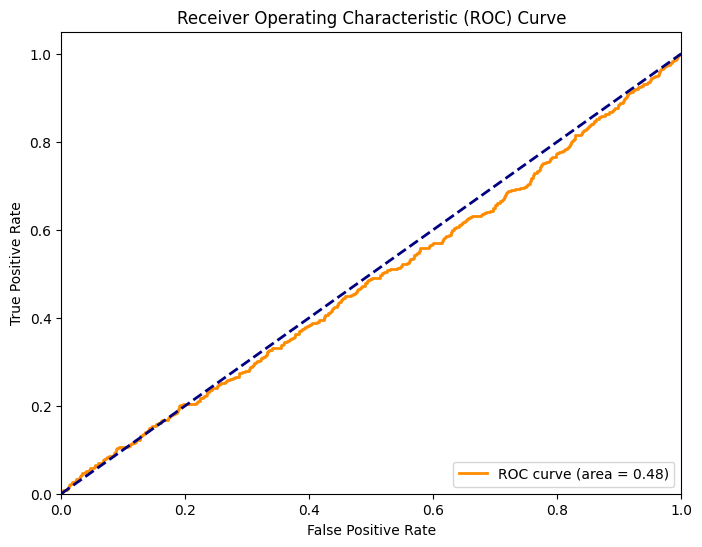

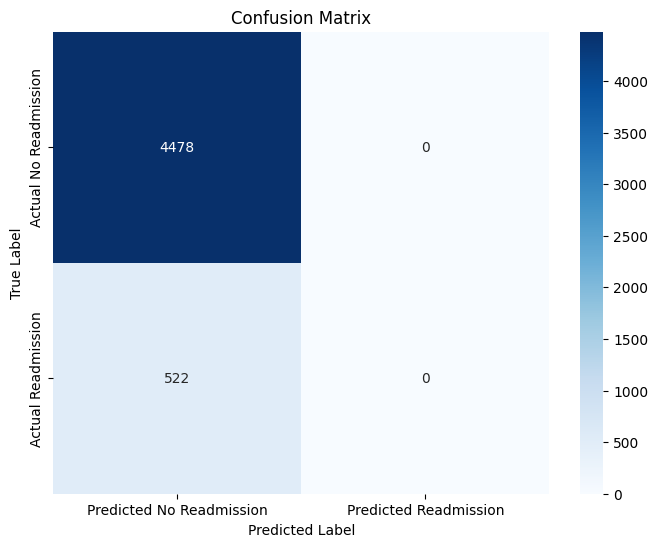


--- Clinical Cost Discussion ---
False Negatives (Type II Error): These occur when the model predicts 'No Readmission' but the patient is actually readmitted. In a clinical context, false negatives can be very costly. A patient who is falsely predicted to not be readmitted might not receive necessary follow-up care, leading to potential health deterioration, increased severity of illness, and eventually, higher medical costs and poorer patient outcomes upon actual readmission. It can also lead to decreased patient trust and satisfaction.

False Positives (Type I Error): These occur when the model predicts 'Readmission' but the patient is actually not readmitted. In a clinical context, false positives would lead to unnecessary interventions, such as extra follow-up appointments, additional monitoring, or even premature readmission into a hospital. This can lead to increased healthcare costs due to overuse of resources, patient inconvenience, and potentially unnecessary anxiety for the 

In [5]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No Readmission', 'Predicted Readmission'], yticklabels=['Actual No Readmission', 'Actual Readmission'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\n--- Clinical Cost Discussion ---")
print("False Negatives (Type II Error): These occur when the model predicts 'No Readmission' but the patient is actually readmitted. In a clinical context, false negatives can be very costly. A patient who is falsely predicted to not be readmitted might not receive necessary follow-up care, leading to potential health deterioration, increased severity of illness, and eventually, higher medical costs and poorer patient outcomes upon actual readmission. It can also lead to decreased patient trust and satisfaction.")
print("\nFalse Positives (Type I Error): These occur when the model predicts 'Readmission' but the patient is actually not readmitted. In a clinical context, false positives would lead to unnecessary interventions, such as extra follow-up appointments, additional monitoring, or even premature readmission into a hospital. This can lead to increased healthcare costs due to overuse of resources, patient inconvenience, and potentially unnecessary anxiety for the patient.")
print("\nBalancing Act: The choice of threshold for readmission prediction (which dictates the trade-off between false positives and false negatives) depends heavily on the clinical context and the priorities of the healthcare system. If the goal is to minimize patient harm and ensure optimal care, the threshold might be adjusted to be more sensitive to readmissions (tolerating more false positives to reduce false negatives). If resource utilization and cost containment are paramount, a higher specificity (tolerating more false negatives to reduce false positives) might be preferred.")